# Category-CRP

> Compare transition probabilities for same-category vs. different-category items.

The category-CRP bins recall transitions into *same category* and *different category* using a single feature column from a categorical embedding matrix. This is a convenience wrapper around the distance-CRP machinery, using fixed bins rather than continuous distance quantiles.

A higher same-category transition probability indicates category clustering in recall: participants preferentially transition to items sharing a category with the just-recalled item.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import warnings
from jaxcmr.analyses.distcrp import plot_cat_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/CohenKahana2022_noELI.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['session'] == 1"
category_features_path = "data/emotion_features_7col.npy"
feature_column = 6
feature_label = "Emotionality"
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
category_features = np.load(os.path.join(project_root, category_features_path))

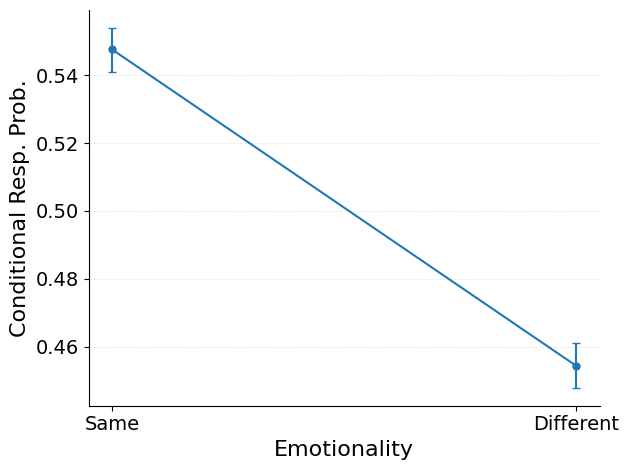

In [4]:
plot_cat_crp(
    datasets=data,
    trial_masks=trial_mask,
    features=category_features,
    feature_column=feature_column,
    feature_label=feature_label,
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The plot shows transition probabilities for same-category and different-category items. Key patterns:

- **Same > Different**: participants cluster recalls within categories, transitioning preferentially to items sharing a category with the just-recalled item.
- **Same ≈ Different**: category membership does not organize recall transitions.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `category_features_path` — path to a numpy file containing category labels (shape: `[word_count, n_features]`).
- `feature_column` — which column in the features array to use for categorization.
- `feature_label` — label for the category feature in the plot legend.
- `confidence_level` — confidence level for subject-wise error bars.